# 🔁 Notebook-04: Vollständiger ML-Modellierungszyklus
**KI Advanced · IA1017000 · HfPolBW · Marc Brandt**

---

| | |
|---|---|
| **Session** | S 2.1 – ML-Modellierung & Validierung |
| **Datensatz** | `polizei_testdatensatz_v4_1200faelle.csv` – 1.200 Fälle aus BW |
| **Zielvariable** | `risiko_einstufung` – Fall-Risikoeinstufung nach Komplexität & Gefährlichkeit |
| **Dauer** | ~25 Minuten |

> **Ausführen:** *Runtime → Run all* (Colab) · *Kernel → Restart & Run All* (JupyterLab)

---

## Was soll das Modell lernen?

**Ziel:** Für einen neuen Fall automatisch einschätzen, ob er als  
**niedrig · mittel · hoch** einzustufen ist – nach Komplexität und Gefährlichkeit.

**Nutzen in der Praxis:**
- Priorisierung von Ermittlungsressourcen
- Frühzeitige Einschätzung des Ermittlungsaufwands
- Unterstützung bei der Fallzuweisung an Spezialdienststellen

> ⚠️ **Wichtige Einschränkung:** KI unterstützt – sie entscheidet nicht.  
> Die Einstufung ist ein Hilfsmittel, kein Urteil. Jeder Fall braucht menschliche Bewertung.

---

## Ablauf

```
CSV laden & erkunden
    ↓
[1] Zielvariable transparent definieren  ← NEU: explizites Bewertungsschema
    ↓
[2] Feature-Auswahl begründen            ← welche Features machen inhaltlich Sinn?
    ↓
[3] Preprocessing                        ← Encoding, Skalierung, Split
    ↓
[4] Baseline-Modell                      ← Logistische Regression als Referenz
    ↓
[5] Overfitting diagnostizieren          ← Lernkurven
    ↓
[6] Regularisierung                      ← Gegenmittel
    ↓
[7] Grid Search + Test-Evaluation        ← bestes Modell, ehrlicher Test
```


---
## ⚙️ Setup – Bibliotheken laden


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings; warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score
)

C = {
    'navy':'#001E46','blue1':'#0D3761','blue2':'#1A4E8A','blue3':'#0A2A50',
    'ice':'#4FC3F7','orange':'#ED7D31','green':'#52B788','teal':'#00B4D8',
    'lgray':'#B0C4DE','white':'#FFFFFF','purple':'#9B59B6',
    'gold':'#FFC300','red':'#E74C3C','pink':'#E91E8C',
}
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor':C['navy'], 'axes.facecolor':C['blue1'],
    'axes.edgecolor':C['lgray'],  'axes.labelcolor':C['lgray'],
    'xtick.color':C['lgray'],     'ytick.color':C['lgray'],
    'text.color':C['white'],      'grid.color':'#1A4E8A',
    'grid.alpha':0.4,             'font.size':11,
})
print('✅  Setup OK')


✅  Setup OK


---
## Datensatz laden

1.200 anonymisierte Polizei-Fälle aus Baden-Württemberg.  
Jede Zeile = ein Fall. Jede Spalte = ein Merkmal des Falls.


In [2]:
# ── CSV direkt von GitHub laden ───────────────────────────────────────────────
# Funktioniert in Google Colab, JupyterLab und lokal – kein Upload nötig.
# Wichtig: Wir nutzen die RAW-URL (raw.githubusercontent.com), nicht die
# normale GitHub-Seite. pd.read_csv() braucht einen direkten Dateilink.

GITHUB_URL = "https://raw.githubusercontent.com/mb4n6/AI_Advanced/main/polizei_testdatensatz_v4_1200faelle.csv"

print(f"Lade Datensatz von GitHub...")
print(f"  URL: {GITHUB_URL}")
print()

df_raw = pd.read_csv(GITHUB_URL)

print(f"✅  Geladen: {df_raw.shape[0]} Fälle  ·  {df_raw.shape[1]} Spalten")


Lade Datensatz von GitHub...
  URL: https://raw.githubusercontent.com/mb4n6/AI_Advanced/main/polizei_testdatensatz_v4_1200faelle.csv

✅  Geladen: 1200 Fälle  ·  22 Spalten


---

## Teil 1 – Zielvariable definieren: Was bedeutet „Fallrisiko"?

### Warum müssen wir das explizit definieren?

Der Datensatz enthält eine Spalte `risiko_klasse` – aber **ohne dokumentierte Definition**  
ist unklar, was sie misst. Für ein praxistaugliches KI-System ist das inakzeptabel:

> Ein Modell kann nur so gut sein wie die Labels, auf denen es trainiert wird.  
> **Garbage Labels → Garbage Model.**

Wir definieren die Zielvariable deshalb **transparent und nachvollziehbar**  
aus messbaren Fallmerkmalen.

---

### Definition: Fall-Risikoeinstufung

> **Risikoeinstufung eines Falls** = Einschätzung von **Gefährlichkeit** und **Komplexität**  
> auf Basis objektiver, im Ermittlungssystem erfasster Merkmale.

**Nicht gemeint:** Rückfallrisiko einer Person, Schuld, Persönlichkeitsmerkmale.  
**Gemeint:** Wie gefährlich und komplex ist dieser *Fall* für die Ermittlung?

---

### Das Bewertungsschema: 4 Dimensionen

Das Modell soll Fälle entlang von vier Dimensionen einstufen:

| Dimension | Was sie misst | Features |
|---|---|---|
| **A · Schadenspotenzial** | Wirtschaftlicher Schaden des Delikts | `schadenshoehe_eur` |
| **B · Täterstruktur** | Gefährlichkeit des Täterumfelds | `vorstrafen_bekannt`, `anzahl_verdaechtige` |
| **C · Planungsgrad** | Organisierter, geplanter Charakter der Tat | `netzwerk_score`, `vorplanungszeit_h`, `kommunikation_events` |
| **D · Ermittlungsaufwand** | Spurenlage und Ressourcenbedarf | `digitale_spuren`, `osint_hinweise`, `gps_daten_vorhanden`, `video_cctv` |

**Einstufung:**

| Klasse | Gesamtpunkte | Bedeutung |
|---|---|---|
| `niedrig` | 0–3 | Unkomplizierter Fall, Standardbearbeitung |
| `mittel`  | 4–6 | Erhöhter Aufwand, ggf. Sonderdienststelle |
| `hoch`    | 7–12 | Komplexer Fall, Spezialdienststelle, erhöhte Ressourcen |

---

### Welche Features werden **nicht** verwendet – und warum?

| Feature | Warum ausgeschlossen |
|---|---|
| `deliktart` | Fast gleichmäßige Verteilung über alle Risikoklassen → kein Informationsgehalt |
| `tatmittel` | Ähnliches Bild – Mittel allein bestimmt keine Komplexität |
| `tatort_stadt` | Ort soll keine Rolle spielen (Gleichbehandlung) |
| `tatort_urban` / `tatzeit_nacht` | Statistisch kaum unterschiedlich je Klasse |
| `mobilfunk_provider` | Kein inhaltlicher Zusammenhang mit Fallrisiko |
| `geraet_typ` | Marginaler Beitrag, erhöht unnötig die Modellkomplexität |

> 💡 **Das ist eine Modellentscheidung, keine technische Notwendigkeit.**  
> KI-Modelle können mit allen Features trainiert werden – aber nur weil ein Merkmal  
> statistisch korreliert, bedeutet das nicht, dass es *sinnvoll* ist es zu verwenden.  
> **Beispiel:** Ein Modell das nach `tatort_stadt` diskriminiert, wäre rechtlich problematisch.


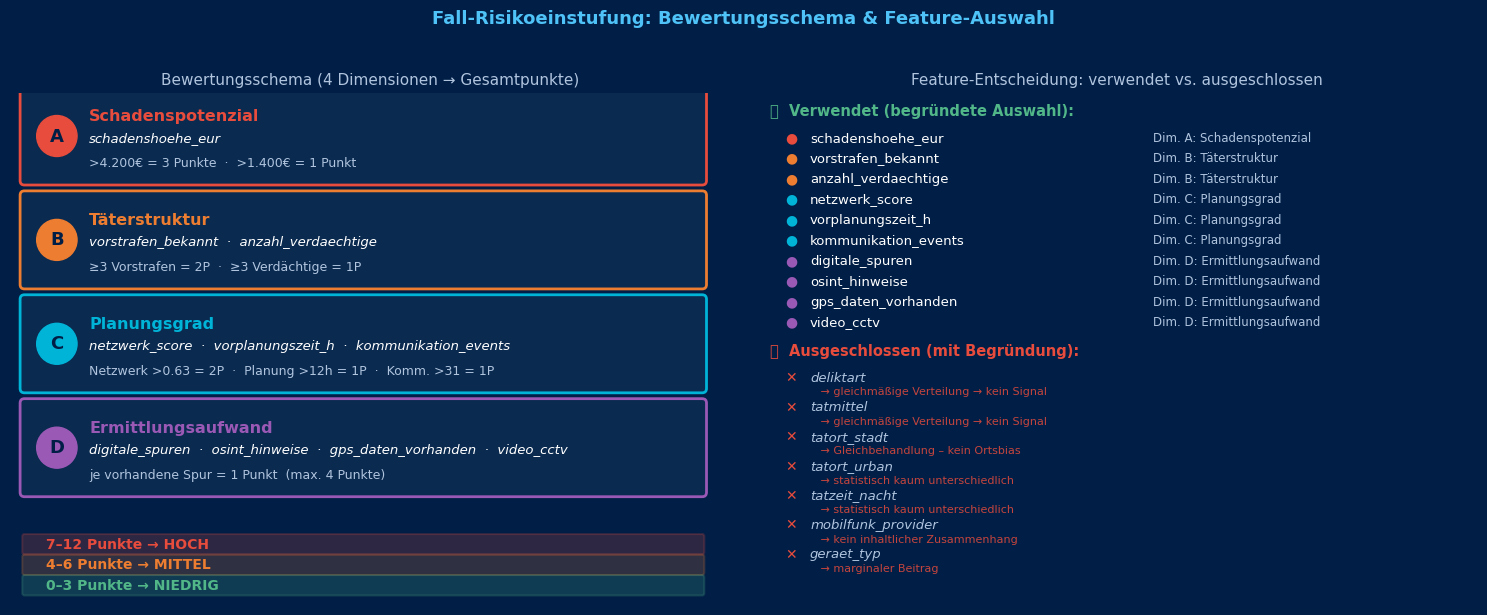

Bewertungsschema angezeigt


In [3]:
# ── Bewertungsschema visualisieren ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Fall-Risikoeinstufung: Bewertungsschema & Feature-Auswahl',
             fontsize=13, color=C['ice'], fontweight='bold', y=1.02)

# ── Linke Grafik: Bewertungsschema ────────────────────────────────────────────
ax1 = axes[0]
ax1.set_xlim(0, 10); ax1.set_ylim(0, 7); ax1.axis('off')
ax1.set_title('Bewertungsschema (4 Dimensionen → Gesamtpunkte)',
              color=C['lgray'], fontsize=11)

dimensionen = [
    (C['red'],    'A', 'Schadenspotenzial',
     'schadenshoehe_eur',
     '>4.200€ = 3 Punkte  ·  >1.400€ = 1 Punkt'),
    (C['orange'], 'B', 'Täterstruktur',
     'vorstrafen_bekannt  ·  anzahl_verdaechtige',
     '≥3 Vorstrafen = 2P  ·  ≥3 Verdächtige = 1P'),
    (C['teal'],   'C', 'Planungsgrad',
     'netzwerk_score  ·  vorplanungszeit_h  ·  kommunikation_events',
     'Netzwerk >0.63 = 2P  ·  Planung >12h = 1P  ·  Komm. >31 = 1P'),
    (C['purple'], 'D', 'Ermittlungsaufwand',
     'digitale_spuren  ·  osint_hinweise  ·  gps_daten_vorhanden  ·  video_cctv',
     'je vorhandene Spur = 1 Punkt  (max. 4 Punkte)'),
]

for i, (col, letter, titel, features, detail) in enumerate(dimensionen):
    y = 5.8 - i * 1.42
    rect = mpatches.FancyBboxPatch((0.2, y), 9.4, 1.22,
        boxstyle='round,pad=0.06', facecolor=C['blue3'],
        edgecolor=col, linewidth=2, zorder=2)
    ax1.add_patch(rect)
    # Kreis mit Buchstabe
    circ = plt.Circle((0.65, y+0.61), 0.28, color=col, zorder=3)
    ax1.add_patch(circ)
    ax1.text(0.65, y+0.61, letter, ha='center', va='center',
             fontsize=13, fontweight='bold', color=C['navy'], zorder=4)
    ax1.text(1.1, y+0.88, titel, fontsize=11.5, color=col,
             fontweight='bold', va='center', zorder=3)
    ax1.text(1.1, y+0.58, features, fontsize=9.5, color=C['white'],
             va='center', zorder=3, style='italic')
    ax1.text(1.1, y+0.24, detail, fontsize=9, color=C['lgray'],
             va='center', zorder=3)

# Schwellenwert-Legende
for y_pos, pts, label, col in [(0.72, '7–12', 'HOCH', C['red']),
                                 (0.44, '4–6',  'MITTEL', C['orange']),
                                 (0.16, '0–3',  'NIEDRIG', C['green'])]:
    rect2 = mpatches.FancyBboxPatch((0.2, y_pos), 9.4, 0.22,
        boxstyle='round,pad=0.03', facecolor=col, alpha=0.2,
        edgecolor=col, linewidth=1.5, zorder=2)
    ax1.add_patch(rect2)
    ax1.text(0.5, y_pos+0.11, f'{pts} Punkte → {label}',
             fontsize=10, color=col, fontweight='bold', va='center', zorder=3)

# ── Rechte Grafik: Feature-Entscheidung (verwendet vs. ausgeschlossen) ────────
ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(0, 8); ax2.axis('off')
ax2.set_title('Feature-Entscheidung: verwendet vs. ausgeschlossen',
              color=C['lgray'], fontsize=11)

verwendet = [
    ('schadenshoehe_eur',       'A', C['red'],    'Schadenspotenzial'),
    ('vorstrafen_bekannt',      'B', C['orange'], 'Täterstruktur'),
    ('anzahl_verdaechtige',     'B', C['orange'], 'Täterstruktur'),
    ('netzwerk_score',          'C', C['teal'],   'Planungsgrad'),
    ('vorplanungszeit_h',       'C', C['teal'],   'Planungsgrad'),
    ('kommunikation_events',    'C', C['teal'],   'Planungsgrad'),
    ('digitale_spuren',         'D', C['purple'], 'Ermittlungsaufwand'),
    ('osint_hinweise',          'D', C['purple'], 'Ermittlungsaufwand'),
    ('gps_daten_vorhanden',     'D', C['purple'], 'Ermittlungsaufwand'),
    ('video_cctv',              'D', C['purple'], 'Ermittlungsaufwand'),
]
ausgeschlossen = [
    ('deliktart',          'gleichmäßige Verteilung → kein Signal'),
    ('tatmittel',          'gleichmäßige Verteilung → kein Signal'),
    ('tatort_stadt',       'Gleichbehandlung – kein Ortsbias'),
    ('tatort_urban',       'statistisch kaum unterschiedlich'),
    ('tatzeit_nacht',      'statistisch kaum unterschiedlich'),
    ('mobilfunk_provider', 'kein inhaltlicher Zusammenhang'),
    ('geraet_typ',         'marginaler Beitrag'),
]

ax2.text(0.2, 7.65, '✅  Verwendet (begründete Auswahl):', fontsize=10.5,
         color=C['green'], fontweight='bold')
for i, (feat, dim, col, gruppe) in enumerate(verwendet):
    y = 7.3 - i*0.32
    ax2.text(0.4, y, f'●', fontsize=10, color=col, va='center')
    ax2.text(0.75, y, feat, fontsize=9.5, color=C['white'], va='center')
    ax2.text(5.5, y, f'Dim. {dim}: {gruppe}', fontsize=8.5,
             color=C['lgray'], va='center')

ax2.text(0.2, 3.9, '❌  Ausgeschlossen (mit Begründung):', fontsize=10.5,
         color=C['red'], fontweight='bold')
for i, (feat, grund) in enumerate(ausgeschlossen):
    y = 3.55 - i*0.46
    ax2.text(0.4, y, f'✕', fontsize=10, color=C['red'], va='center')
    ax2.text(0.75, y, feat, fontsize=9.5, color=C['lgray'],
             va='center', style='italic')
    ax2.text(0.75, y-0.22, f'   → {grund}', fontsize=8, color=C['red'],
             va='center', alpha=0.85)

plt.tight_layout()
plt.show()
print('Bewertungsschema angezeigt')


### Zielvariable transparent berechnen

Das Bewertungsschema wird jetzt **im Code umgesetzt** – jede Entscheidungsregel ist lesbar.  
Das ist ein zentrales Qualitätsmerkmal für KI in der öffentlichen Verwaltung:  
**Nachvollziehbarkeit jeder Einstufung**.

> 💡 Mit diesem Schema kann jederzeit erklärt werden, **warum** ein Fall als „hoch" eingestuft wird.  
> Das wäre mit einem Black-Box-Modell allein nicht möglich.


In [4]:
# ── Transparentes Bewertungsschema ───────────────────────────────────────────
# Jede Regel ist explizit – keine versteckte Logik

def berechne_risikopunkte(row):
    """
    Berechnet Risikopunkte nach 4 Dimensionen.
    Gibt Gesamt-Punkte (0-12) und Einzelbeiträge zurück.
    """
    punkte = {}

    # ── Dimension A: Schadenspotenzial ───────────────────────────────────────
    # Schwellen: p66=4.237 EUR, p33=1.388 EUR (Daten-Perzentile)
    if row['schadenshoehe_eur'] > 4237:
        punkte['A_schaden'] = 3    # Großschaden
    elif row['schadenshoehe_eur'] > 1388:
        punkte['A_schaden'] = 1    # Mittelschaden
    else:
        punkte['A_schaden'] = 0    # Geringer Schaden

    # ── Dimension B: Täterstruktur ───────────────────────────────────────────
    if row['vorstrafen_bekannt'] >= 3:
        punkte['B_vorstrafen'] = 2   # Mehrfach vorbestraft
    elif row['vorstrafen_bekannt'] >= 1:
        punkte['B_vorstrafen'] = 1   # Vorbestraft
    else:
        punkte['B_vorstrafen'] = 0   # Keine Vorstrafen bekannt

    punkte['B_verdaechtige'] = 1 if row['anzahl_verdaechtige'] >= 3 else 0

    # ── Dimension C: Planungsgrad / Organisationsgrad ────────────────────────
    # p66=0.63, p33=0.41 für netzwerk_score
    if row['netzwerk_score'] > 0.63:
        punkte['C_netzwerk'] = 2     # Starkes Netzwerk
    elif row['netzwerk_score'] > 0.41:
        punkte['C_netzwerk'] = 1     # Mittleres Netzwerk
    else:
        punkte['C_netzwerk'] = 0

    # p66=11.92 für vorplanungszeit_h
    punkte['C_planung'] = 1 if row['vorplanungszeit_h'] > 11.92 else 0

    # p66=31 für kommunikation_events
    punkte['C_kommunikation'] = 1 if row['kommunikation_events'] > 31 else 0

    # ── Dimension D: Ermittlungsaufwand ──────────────────────────────────────
    # Binäre Merkmale: jedes vorhandene Spurenmerkmal = 1 Punkt
    punkte['D_spuren'] = (
        int(row['digitale_spuren']) +
        int(row['osint_hinweise']) +
        int(row['gps_daten_vorhanden']) +
        int(row['video_cctv'])
    )

    punkte['gesamt'] = sum(v for k, v in punkte.items() if k != 'gesamt')
    return punkte

# ── Punkte für alle Fälle berechnen ──────────────────────────────────────────
punkte_details = df_raw.apply(berechne_risikopunkte, axis=1)
df_raw['punkte_gesamt'] = punkte_details.apply(lambda x: x['gesamt'])

# ── Einstufung nach Schwellenwerten ──────────────────────────────────────────
# Schwellen: p33=3, p66=6 (aus der Punkte-Verteilung)
def einstufen(punkte):
    if punkte >= 7:   return 'hoch'
    elif punkte >= 4: return 'mittel'
    else:             return 'niedrig'

df_raw['risiko_einstufung'] = df_raw['punkte_gesamt'].apply(einstufen)

# ── Ergebnis ausgeben ─────────────────────────────────────────────────────────
print('ZIELVARIABLE: risiko_einstufung')
print('=' * 50)
vc = df_raw['risiko_einstufung'].value_counts()
for klasse in ['hoch', 'mittel', 'niedrig']:
    n = vc.get(klasse, 0)
    balken = '█' * (n // 20)
    print(f'  {klasse:<10}: {n:>5} Fälle ({n/len(df_raw):.0%})  {balken}')

print()
print('Punkte-Verteilung:')
print(f'  Min:    {df_raw["punkte_gesamt"].min():.0f}')
print(f'  Median: {df_raw["punkte_gesamt"].median():.0f}')
print(f'  Max:    {df_raw["punkte_gesamt"].max():.0f}')

# Beispiel: Einen konkreten Fall erklären
print()
print('BEISPIEL-BEGRÜNDUNG für Fall 0:')
p = berechne_risikopunkte(df_raw.iloc[0])
print(f'  Delikt: {df_raw.iloc[0]["deliktart"]}')
for dim, wert in p.items():
    if dim != 'gesamt' and wert > 0:
        print(f'  {dim:<20}: +{wert} Punkt(e)')
print(f'  {"GESAMT":<20}: {p["gesamt"]} Punkte → {df_raw.iloc[0]["risiko_einstufung"].upper()}')


ZIELVARIABLE: risiko_einstufung
  hoch      :   563 Fälle (47%)  ████████████████████████████
  mittel    :   338 Fälle (28%)  ████████████████
  niedrig   :   299 Fälle (25%)  ██████████████

Punkte-Verteilung:
  Min:    0
  Median: 6
  Max:    14

BEISPIEL-BEGRÜNDUNG für Fall 0:
  Delikt: Raub
  A_schaden           : +3 Punkt(e)
  B_vorstrafen        : +1 Punkt(e)
  C_netzwerk          : +2 Punkt(e)
  D_spuren            : +2 Punkt(e)
  GESAMT              : 8 Punkte → HOCH


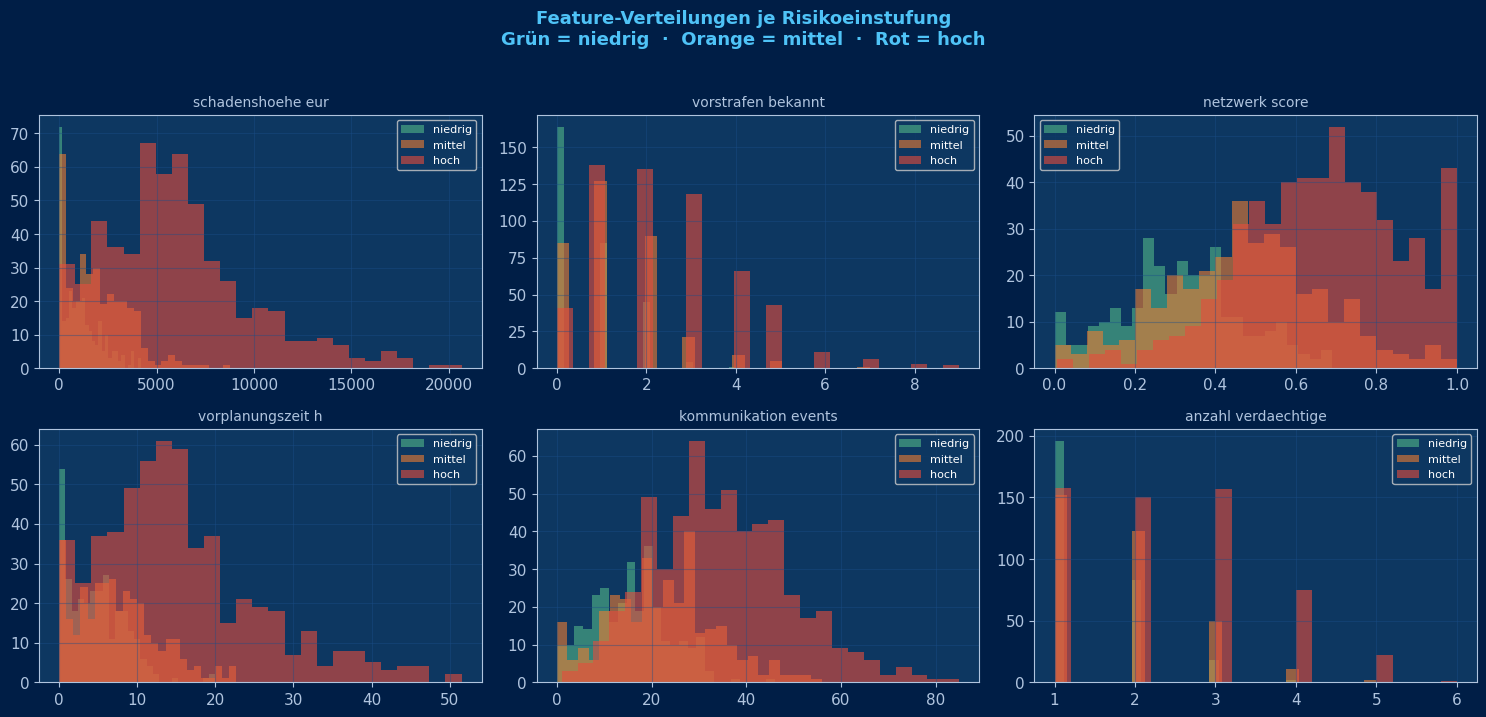

Beobachtungen:
  vorstrafen_bekannt:   deutliche Trennung hoch > mittel > niedrig ✅
  netzwerk_score:       klare Trennung ✅
  vorplanungszeit_h:    gute Trennung ✅
  schadenshoehe_eur:    moderate Trennung ✅

→ Diese Verteilungen bestätigen: Die gewählten Features tragen
  zur Klassifikation bei. Das Bewertungsschema ist konsistent.


In [5]:
# ── Feature-Verteilungen je Risikoklasse ──────────────────────────────────────
# Kontrolle: Trennen die ausgewählten Features die Klassen gut?

verwendet_feats = [
    'schadenshoehe_eur', 'vorstrafen_bekannt', 'netzwerk_score',
    'vorplanungszeit_h', 'kommunikation_events', 'anzahl_verdaechtige',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Feature-Verteilungen je Risikoeinstufung\n'
             'Grün = niedrig  ·  Orange = mittel  ·  Rot = hoch',
             fontsize=13, color=C['ice'], fontweight='bold', y=1.02)

klassen_order  = ['niedrig', 'mittel', 'hoch']
klassen_farben = [C['green'], C['orange'], C['red']]

for i, feat in enumerate(verwendet_feats):
    ax = axes[i//3][i%3]
    for klasse, farbe in zip(klassen_order, klassen_farben):
        mask = df_raw['risiko_einstufung'] == klasse
        ax.hist(df_raw.loc[mask, feat], bins=25, alpha=0.6,
                color=farbe, label=klasse)
    ax.set_title(feat.replace('_', ' '), color=C['lgray'], fontsize=10)
    ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout(); plt.show()

print('Beobachtungen:')
print('  vorstrafen_bekannt:   deutliche Trennung hoch > mittel > niedrig ✅')
print('  netzwerk_score:       klare Trennung ✅')
print('  vorplanungszeit_h:    gute Trennung ✅')
print('  schadenshoehe_eur:    moderate Trennung ✅')
print()
print('→ Diese Verteilungen bestätigen: Die gewählten Features tragen')
print('  zur Klassifikation bei. Das Bewertungsschema ist konsistent.')


---

## Teil 2 – Preprocessing: Daten für das Modell aufbereiten

Wir haben jetzt:
- Eine klar definierte Zielvariable (`risiko_einstufung`)
- Eine begründete Feature-Auswahl (10 Features aus 4 Dimensionen)

**Was noch zu tun ist:**

| Schritt | Warum |
|---|---|
| **Zielvariable kodieren** | Modelle brauchen Zahlen: `niedrig→0, mittel→1, hoch→2` |
| **Daten aufteilen** | Train/Validation/Test – Modell darf Test nie sehen |
| **Skalieren** | `schadenshoehe_eur` (0–20.000) vs. `netzwerk_score` (0–1) – nicht vergleichbar |

> 💡 Keine fehlenden Werte im Datensatz → kein Imputation-Schritt nötig.  
> In der Praxis sind fehlende Werte jedoch die Regel, nicht die Ausnahme.


In [6]:
# ── Feature-Auswahl: nur die 10 begründeten Features ─────────────────────────
FEATS_VERWENDET = [
    # Dimension A: Schadenspotenzial
    'schadenshoehe_eur',
    # Dimension B: Täterstruktur
    'vorstrafen_bekannt', 'anzahl_verdaechtige',
    # Dimension C: Planungsgrad
    'netzwerk_score', 'vorplanungszeit_h', 'kommunikation_events',
    # Dimension D: Ermittlungsaufwand
    'digitale_spuren', 'osint_hinweise', 'gps_daten_vorhanden', 'video_cctv',
]

X_raw = df_raw[FEATS_VERWENDET].values   # nur die 10 Features als numpy-Array

# ── Zielvariable kodieren ─────────────────────────────────────────────────────
# LabelEncoder weist Zahlen zu: alphabetisch → hoch=0, mittel=1, niedrig=2
# ABER: wir erzwingen sinnvolle Reihenfolge: niedrig=0, mittel=1, hoch=2
klassen_reihenfolge = ['niedrig', 'mittel', 'hoch']
klassen_zu_zahl     = {k: i for i, k in enumerate(klassen_reihenfolge)}
y = df_raw['risiko_einstufung'].map(klassen_zu_zahl).values

print('Zielvariable-Kodierung:')
for text, zahl in klassen_zu_zahl.items():
    n = (y == zahl).sum()
    print(f'  {text:<10} → {zahl}  ({n} Fälle, {n/len(y):.0%})')

n_total = len(X_raw)

# ── Train / Validation / Test aufteilen ──────────────────────────────────────
# Schritt 1: 15% Test reservieren (gesperrt bis zum Ende)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y, test_size=0.15, random_state=42, stratify=y
)
# Schritt 2: 15% Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print()
print('Datensatz aufgeteilt:')
print(f'  Training:   {len(X_train):4d} Fälle ({len(X_train)/n_total:.0%})')
print(f'  Validation: {len(X_val):4d} Fälle ({len(X_val)/n_total:.0%})')
print(f'  Test:       {len(X_test):4d} Fälle ({len(X_test)/n_total:.0%})  🔒 gesperrt')

# ── Skalierung (RobustScaler) ─────────────────────────────────────────────────
# Warum RobustScaler? schadenshoehe_eur hat Ausreißer bis 20.000 EUR.
# RobustScaler nutzt Median + IQR statt Mittelwert + Std → ausreißer-tolerant.
scaler = RobustScaler()
X_tr = scaler.fit_transform(X_train)  # NUR auf Trainingsdaten anpassen
X_va = scaler.transform(X_val)
X_te = scaler.transform(X_test)

print()
print(f'Features: {len(FEATS_VERWENDET)} (begründete Auswahl)')
print('✅  Preprocessing abgeschlossen')
print('⚠️  Scaler wurde NUR auf Trainingsdaten gefittet!')


Zielvariable-Kodierung:
  niedrig    → 0  (299 Fälle, 25%)
  mittel     → 1  (338 Fälle, 28%)
  hoch       → 2  (563 Fälle, 47%)

Datensatz aufgeteilt:
  Training:    840 Fälle (70%)
  Validation:  180 Fälle (15%)
  Test:        180 Fälle (15%)  🔒 gesperrt

Features: 10 (begründete Auswahl)
✅  Preprocessing abgeschlossen
⚠️  Scaler wurde NUR auf Trainingsdaten gefittet!


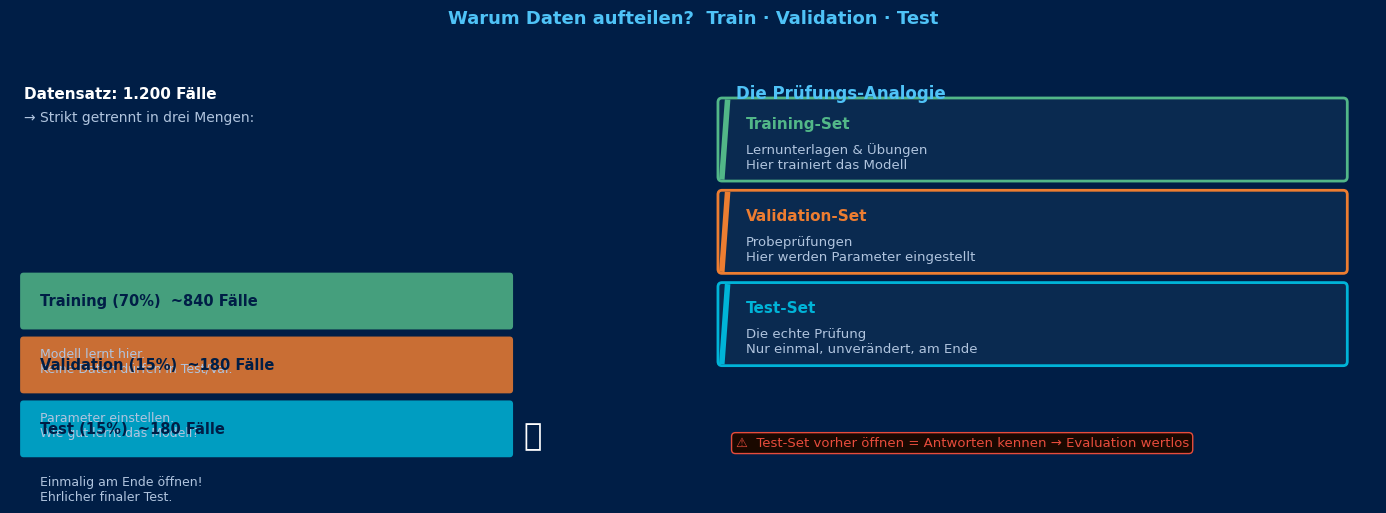

In [7]:
# ── Konzept: Train/Val/Test-Split ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Warum Daten aufteilen?  Train · Validation · Test',
             fontsize=13, color=C['ice'], fontweight='bold', y=1.02)

ax1 = axes[0]
ax1.set_xlim(0, 10); ax1.set_ylim(0, 5.5); ax1.axis('off')

splits_info = [
    (C['green'],  'Training (70%)  ~840 Fälle',
     'Modell lernt hier.\nKeine Daten dürfen in Test/Val.', 1.9),
    (C['orange'], 'Validation (15%)  ~180 Fälle',
     'Parameter einstellen.\nWie gut lernt das Modell?', 1.0),
    (C['teal'],   'Test (15%)  ~180 Fälle',
     'Einmalig am Ende öffnen!\nEhrlicher finaler Test.', 0.1),
]
ax1.text(0.2, 5.1, 'Datensatz: 1.200 Fälle', fontsize=11,
         color=C['white'], fontweight='bold')
ax1.text(0.2, 4.78, '→ Strikt getrennt in drei Mengen:',
         fontsize=10, color=C['lgray'])

for col, label, desc, y0 in splits_info:
    rect = mpatches.FancyBboxPatch((0.2, y0), 7.2, 0.7,
        boxstyle='round,pad=0.05', facecolor=col, edgecolor='none',
        alpha=0.85, zorder=2)
    ax1.add_patch(rect)
    ax1.text(0.45, y0+0.35, label, fontsize=10.5, color=C['navy'],
             fontweight='bold', va='center', zorder=3)
    ax1.text(0.45, y0-0.3, desc, fontsize=9, color=C['lgray'],
             va='top', zorder=3)
ax1.text(7.6, 0.35, '🔒', fontsize=22, va='center')

ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(0, 5.5); ax2.axis('off')
ax2.text(0.5, 5.1, 'Die Prüfungs-Analogie', fontsize=12,
         color=C['ice'], fontweight='bold')

for i, (col, titel, text) in enumerate([
    (C['green'],  'Training-Set',   'Lernunterlagen & Übungen\nHier trainiert das Modell'),
    (C['orange'], 'Validation-Set', 'Probeprüfungen\nHier werden Parameter eingestellt'),
    (C['teal'],   'Test-Set',       'Die echte Prüfung\nNur einmal, unverändert, am Ende'),
]):
    y = 4.0 - i * 1.3
    rect = mpatches.FancyBboxPatch((0.3, y), 9.2, 1.05,
        boxstyle='round,pad=0.06', facecolor=C['blue3'],
        edgecolor=col, linewidth=2, zorder=2)
    ax2.add_patch(rect)
    ax2.plot([0.3, 0.38], [y, y+1.05], color=col, linewidth=4, zorder=3)
    ax2.text(0.65, y+0.75, titel, fontsize=11, color=col,
             fontweight='bold', va='center', zorder=3)
    ax2.text(0.65, y+0.28, text, fontsize=9.5, color=C['lgray'],
             va='center', zorder=3)

ax2.text(0.5, 0.2,
    '⚠️  Test-Set vorher öffnen = Antworten kennen → Evaluation wertlos',
    fontsize=9.5, color=C['red'],
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A0800', edgecolor=C['red']))

plt.tight_layout(); plt.show()


---

## Teil 3 – Baseline-Modell: Logistische Regression

### Warum immer zuerst das einfachste Modell?

> Jedes komplexere Modell muss beweisen, dass es sich lohnt.  
> Wenn Random Forest kaum besser ist als Logistische Regression – wozu die Komplexität?

**Logistische Regression** = zieht eine mathematische Grenzlinie zwischen den Klassen.  
Schnell, interpretierbar, gibt Wahrscheinlichkeiten aus.

### Warum F1 statt Accuracy?

| Klasse | Fälle |
|---|---|
| niedrig | ~35 % |
| mittel | ~39 % |
| hoch | ~26 % |

Bei ungleichen Klassen kann ein Modell hohe Accuracy erreichen, indem es einfach  
immer die häufigste Klasse vorhersagt. **F1 (weighted)** berücksichtigt alle Klassen fair.


In [8]:
# ── Baseline: Logistische Regression ─────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_tr, y_train)
y_pred_lr = lr.predict(X_va)

acc_lr = accuracy_score(y_val, y_pred_lr)
f1_lr  = f1_score(y_val, y_pred_lr, average='weighted')
auc_lr = roc_auc_score(y_val, lr.predict_proba(X_va), multi_class='ovr')

print('=' * 55)
print('  BASELINE: Logistische Regression')
print('=' * 55)
print(f'  Accuracy (Val):     {acc_lr:.3f}  ({acc_lr:.1%})')
print(f'  F1 (weighted, Val): {f1_lr:.3f}')
print(f'  ROC-AUC (Val):      {auc_lr:.3f}')
print()
print(classification_report(
    y_val, y_pred_lr,
    target_names=[f'{k} ({i})' for i, k in enumerate(klassen_reihenfolge)]
))
print('─' * 55)
print('💡 Referenzwert gesetzt. Komplexere Modelle müssen besser sein.')


  BASELINE: Logistische Regression
  Accuracy (Val):     0.872  (87.2%)
  F1 (weighted, Val): 0.872
  ROC-AUC (Val):      0.973

              precision    recall  f1-score   support

 niedrig (0)       0.91      0.91      0.91        45
  mittel (1)       0.78      0.76      0.77        51
    hoch (2)       0.91      0.92      0.91        84

    accuracy                           0.87       180
   macro avg       0.87      0.86      0.86       180
weighted avg       0.87      0.87      0.87       180

───────────────────────────────────────────────────────
💡 Referenzwert gesetzt. Komplexere Modelle müssen besser sein.


---

## Teil 4 – Overfitting: Wenn das Modell auswendig lernt

Ein zu komplexes Modell lernt die Trainingsdaten **inklusive Zufälligkeiten** auswendig.  
Bei neuen Fällen versagt es dann – obwohl es auf den Trainingsdaten perfekt war.

**Wie erkennen wir es?**  
Training-Score sehr hoch, Validation-Score viel niedriger → **Lücke = Overfitting-Signal**

> 💡 Im Polizeikontext besonders kritisch: Ein Modell das auf historischen Fällen  
> „perfekt" lernt, kann bei neuen Fällen zuverlässig versagen.


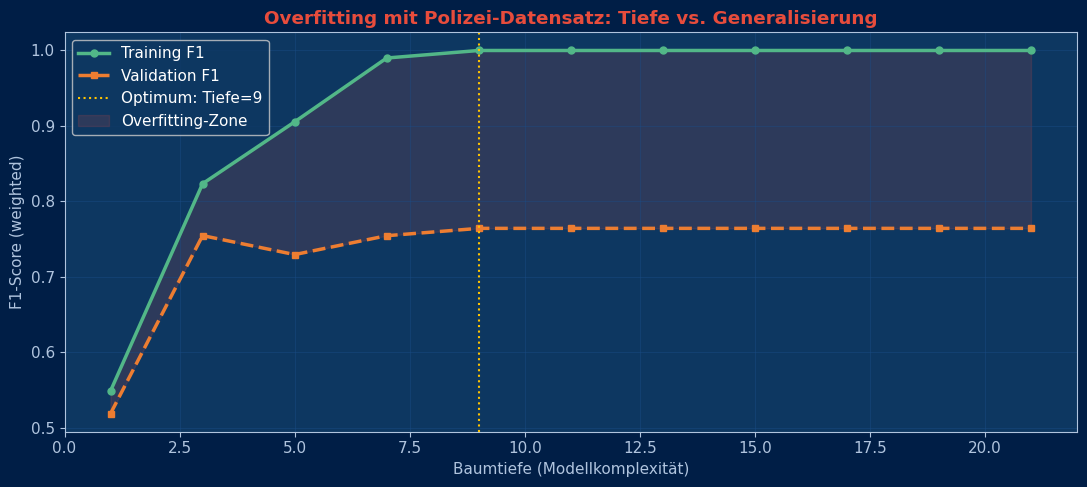

Optimale Tiefe: 9  →  Val-F1: 0.764
Tiefe 21: Training=1.000  Validation=0.764
→ Lücke = 0.236  (Overfitting-Signal)


In [9]:
# ── Overfitting provozieren: kleiner Datensatz + immer tieferer Baum ──────────
X_small = X_tr[:200]; y_small = y_train[:200]

depths    = list(range(1, 22, 2))
tr_scores = []; va_scores = []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_small, y_small)
    tr_scores.append(f1_score(y_small, m.predict(X_small), average='weighted'))
    va_scores.append(f1_score(y_val,   m.predict(X_va),    average='weighted'))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depths, tr_scores, color=C['green'],  lw=2.5,
        marker='o', ms=5, label='Training F1')
ax.plot(depths, va_scores, color=C['orange'], lw=2.5,
        marker='s', ms=5, ls='--', label='Validation F1')

best_idx = np.argmax(va_scores)
ax.axvline(depths[best_idx], color=C['gold'], lw=1.5, ls=':',
           label=f'Optimum: Tiefe={depths[best_idx]}')
ax.fill_between(depths, tr_scores, va_scores,
                where=[t > v for t, v in zip(tr_scores, va_scores)],
                alpha=0.15, color=C['red'], label='Overfitting-Zone')

ax.set_xlabel('Baumtiefe (Modellkomplexität)')
ax.set_ylabel('F1-Score (weighted)')
ax.set_title('Overfitting mit Polizei-Datensatz: Tiefe vs. Generalisierung',
             color=C['red'], fontweight='bold')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()

print(f'Optimale Tiefe: {depths[best_idx]}  →  Val-F1: {max(va_scores):.3f}')
print(f'Tiefe 21: Training={tr_scores[-1]:.3f}  Validation={va_scores[-1]:.3f}')
print(f'→ Lücke = {tr_scores[-1]-va_scores[-1]:.3f}  (Overfitting-Signal)')


---

## Teil 5 – Regularisierung: Overfitting verhindern

| Technik | Idee |
|---|---|
| **L2-Regularisierung** | Bestraft zu große Modell-Gewichte |
| **Kleineres Netz** | Weniger Parameter = weniger Memorisierung |
| **Early Stopping** | Training stoppen bevor Validation-Score sinkt |



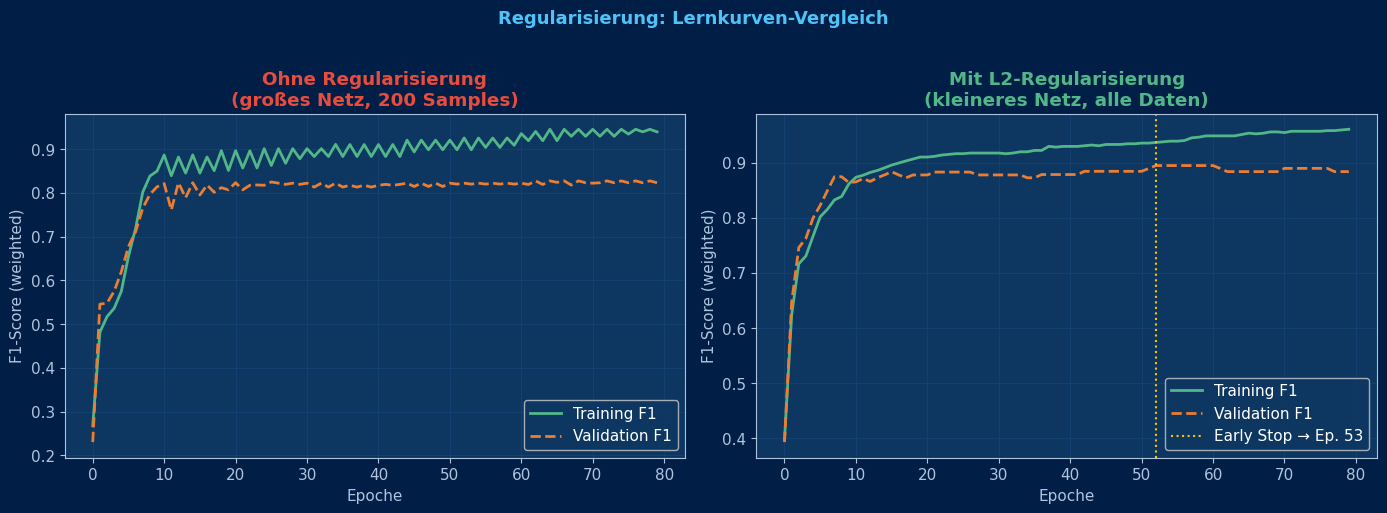

Regularisiertes Modell: Bestes Val-F1 = 0.895 bei Epoche 53


In [10]:
# ── MLP: Ohne vs. Mit Regularisierung ────────────────────────────────────────
mlp_overfit = MLPClassifier(
    hidden_layer_sizes=(256, 256, 128, 64),
    activation='relu', max_iter=1, warm_start=True,
    random_state=42, learning_rate_init=0.001
)
mlp_reg = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu', max_iter=1, warm_start=True,
    random_state=42, alpha=0.01,
    learning_rate_init=0.001
)

N_EP = 80
Xs = X_tr[:200]; ys = y_train[:200]
tr1, va1, tr2, va2 = [], [], [], []
bestes_val=0; beste_ep=0; warten=0; geduld=8

for ep in range(N_EP):
    mlp_overfit.fit(Xs, ys)
    tr1.append(f1_score(ys,    mlp_overfit.predict(Xs),   average='weighted', zero_division=0))
    va1.append(f1_score(y_val, mlp_overfit.predict(X_va), average='weighted', zero_division=0))
    mlp_reg.fit(X_tr, y_train)
    tr2.append(f1_score(y_train, mlp_reg.predict(X_tr),  average='weighted', zero_division=0))
    v = f1_score(y_val, mlp_reg.predict(X_va), average='weighted', zero_division=0)
    va2.append(v)
    if v > bestes_val: bestes_val=v; beste_ep=ep; warten=0
    else: warten+=1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regularisierung: Lernkurven-Vergleich',
             fontsize=13, color=C['ice'], fontweight='bold', y=1.02)
for ax, tr, va, titel, col in zip(axes,
    [tr1, tr2], [va1, va2],
    ['Ohne Regularisierung\n(großes Netz, 200 Samples)',
     'Mit L2-Regularisierung\n(kleineres Netz, alle Daten)'],
    [C['red'], C['green']]):
    ax.plot(tr, color=C['green'],  lw=2, label='Training F1')
    ax.plot(va, color=C['orange'], lw=2, ls='--', label='Validation F1')
    if col==C['green']:
        ax.axvline(beste_ep, color=C['gold'], lw=1.5, ls=':',
                   label=f'Early Stop → Ep. {beste_ep+1}')
    ax.set_xlabel('Epoche'); ax.set_ylabel('F1-Score (weighted)')
    ax.set_title(titel, color=col, fontweight='bold')
    ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

print(f'Regularisiertes Modell: Bestes Val-F1 = {bestes_val:.3f} bei Epoche {beste_ep+1}')


---

## Teil 6 – Lernkurven: Die drei Diagnosen

| Muster | Grüne Linie (Training) | Orange gestrichelt (Validation) | Maßnahme |
|---|---|---|---|
| **Underfitting** | Flach, hoch | Ähnlich flach | Modell komplexer machen |
| **Optimal** | Sinkt stark | Folgt eng | Einfrieren, Test öffnen |
| **Overfitting** | Sinkt weiter | Kippt nach oben | Regularisierung, mehr Daten |


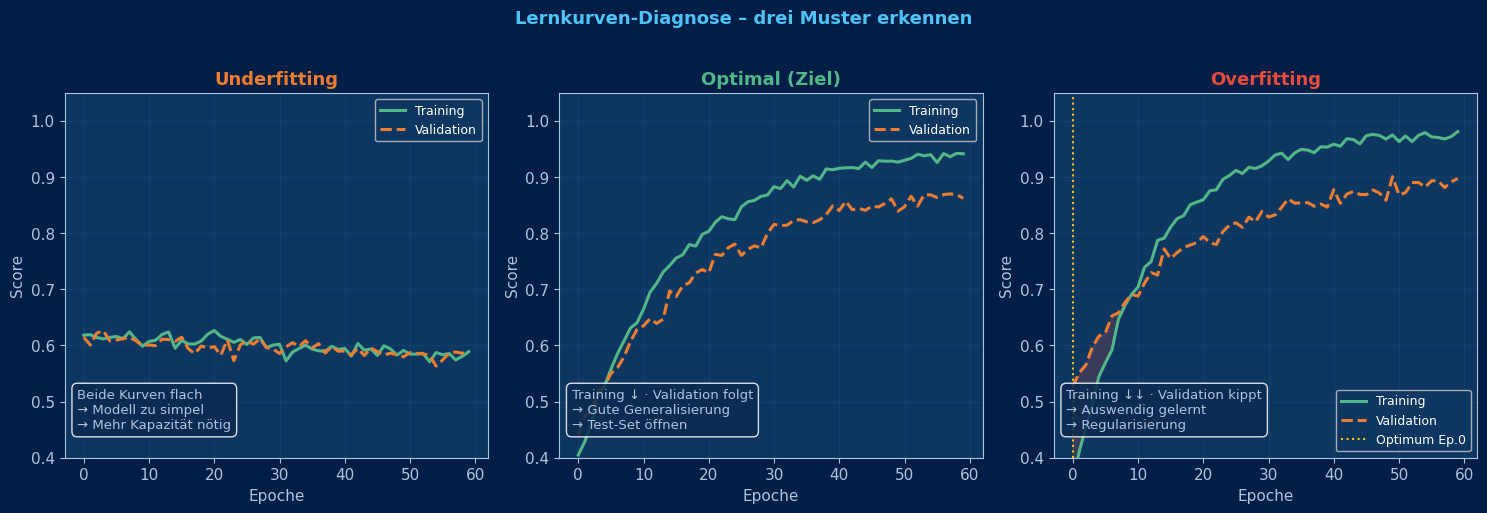

💡 Merksatz: Lernkurven = EKG des Modells. Divergenz = Notfall.


In [11]:
# ── Die drei Diagnose-Muster ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Lernkurven-Diagnose – drei Muster erkennen',
             fontsize=13, color=C['ice'], fontweight='bold', y=1.02)

ep = np.linspace(0, 1, 60)
tr_u = 0.62 - 0.04*ep + np.random.normal(0, 0.008, 60)
va_u = 0.61 - 0.03*ep + np.random.normal(0, 0.010, 60)
tr_o = 0.95 - 0.55*np.exp(-4*ep) + np.random.normal(0, 0.006, 60)
va_o = 0.88 - 0.45*np.exp(-3.5*ep) + np.random.normal(0, 0.009, 60)
tr_v = 0.98 - 0.62*np.exp(-5*ep) + np.random.normal(0, 0.006, 60)
va_v = (0.88 - 0.35*np.exp(-4*ep)) + 0.06*(ep-0.4).clip(0)**2 + np.random.normal(0, 0.009, 60)
best_v = np.argmin(np.abs(va_v - va_v[:30].min()))

configs = [
    (tr_u, va_u, 'Underfitting', C['orange'],
     'Beide Kurven flach\n→ Modell zu simpel\n→ Mehr Kapazität nötig'),
    (tr_o, va_o, 'Optimal (Ziel)', C['green'],
     'Training ↓ · Validation folgt\n→ Gute Generalisierung\n→ Test-Set öffnen'),
    (tr_v, va_v, 'Overfitting', C['red'],
     'Training ↓↓ · Validation kippt\n→ Auswendig gelernt\n→ Regularisierung'),
]
for ax, (tr, va, titel, col, diagnose) in zip(axes, configs):
    ax.plot(tr, color=C['green'],  lw=2.2, label='Training')
    ax.plot(va, color=C['orange'], lw=2.2, ls='--', label='Validation')
    if titel == 'Overfitting':
        ax.axvline(best_v, color=C['gold'], lw=1.5, ls=':',
                   label=f'Optimum Ep.{best_v}')
        ax.fill_between(range(len(tr)), tr, va,
                        where=np.array(tr)<np.array(va),
                        alpha=0.2, color=C['red'])
    ax.set_title(titel, color=col, fontweight='bold', fontsize=13)
    ax.set_xlabel('Epoche'); ax.set_ylabel('Score')
    ax.text(0.03, 0.08, diagnose, transform=ax.transAxes, fontsize=9.5,
            color=C['lgray'],
            bbox=dict(boxstyle='round,pad=0.4', facecolor=C['blue3'], alpha=0.85))
    ax.legend(fontsize=9); ax.grid(True); ax.set_ylim(0.4, 1.05)
plt.tight_layout(); plt.show()
print('💡 Merksatz: Lernkurven = EKG des Modells. Divergenz = Notfall.')


---

## Teil 7 – 🚔 Challenge: Grid Search & finale Evaluation

### Grid Search – automatisch die besten Parameter finden

```
2 × 3 × 2 × 2 = 24 Kombinationen × 5 Folds = 120 Trainingsläufe
```

### Die heilige Regel

> ⚠️ Das Test-Set wird **einmalig, am Ende** geöffnet. Danach kein Nachtunen mehr.


In [12]:
# ── Grid Search ───────────────────────────────────────────────────────────────
param_grid = {
    'n_estimators':      [100, 300],
    'max_depth':         [None, 8, 15],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 0.5],
}
print(f'Grid Search: {2*3*2*2} Kombinationen × 5 Folds = {2*3*2*2*5} Trainingsläufe')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=0
)

X_tv = np.vstack([X_tr, X_va])
y_tv = np.concatenate([y_train, y_val])

print('Grid Search läuft...')
gs.fit(X_tv, y_tv)

print()
print('=' * 60)
print('  GRID SEARCH – ERGEBNISSE')
print('=' * 60)
print(f'  Bester CV-F1 (weighted): {gs.best_score_:.4f}')
print('  Beste Parameter:')
for param, wert in gs.best_params_.items():
    print(f'    {param:<22}: {wert}')
print()
print(f'  Vergleich:')
print(f'    Baseline (Log.Reg.):  F1 = {f1_lr:.4f}')
print(f'    Grid Search RF:       F1 = {gs.best_score_:.4f}  ({(gs.best_score_-f1_lr)/f1_lr*100:+.1f}%)')


Grid Search: 24 Kombinationen × 5 Folds = 120 Trainingsläufe
Grid Search läuft...

  GRID SEARCH – ERGEBNISSE
  Bester CV-F1 (weighted): 0.8844
  Beste Parameter:
    max_depth             : 15
    max_features          : sqrt
    min_samples_split     : 2
    n_estimators          : 300

  Vergleich:
    Baseline (Log.Reg.):  F1 = 0.8718
    Grid Search RF:       F1 = 0.8844  (+1.4%)


### Test-Set öffnen – der Moment der Wahrheit

180 Fälle, die das Modell noch nie gesehen hat.  
**Einmalig, unverfälscht.**


In [13]:
# ── FINALE EVALUATION: Test-Set 🔒 → 🔓 ─────────────────────────────────────
bestes_modell = gs.best_estimator_
y_pred = bestes_modell.predict(X_te)
y_prob = bestes_modell.predict_proba(X_te)

acc_f = accuracy_score(y_test, y_pred)
f1_f  = f1_score(y_test, y_pred, average='weighted')
pre_f = precision_score(y_test, y_pred, average='weighted')
rec_f = recall_score(y_test, y_pred, average='weighted')
auc_f = roc_auc_score(y_test, y_prob, multi_class='ovr')

print('=' * 60)
print('  FINALE TEST-EVALUATION  (180 ungesehene Fälle)')
print('=' * 60)
print(f'  Accuracy:             {acc_f:.4f}  ({acc_f:.1%})')
print(f'  F1 (weighted):        {f1_f:.4f}')
print(f'  Precision (weighted): {pre_f:.4f}')
print(f'  Recall (weighted):    {rec_f:.4f}')
print(f'  ROC-AUC (OvR):        {auc_f:.4f}')
print()
print(classification_report(
    y_test, y_pred,
    target_names=klassen_reihenfolge
))
print('─' * 60)
print(f'  Baseline F1:   {f1_lr:.4f}')
print(f'  Finales F1:    {f1_f:.4f}  ({(f1_f-f1_lr)/f1_lr*100:+.1f}% Verbesserung)')


  FINALE TEST-EVALUATION  (180 ungesehene Fälle)
  Accuracy:             0.8833  (88.3%)
  F1 (weighted):        0.8855
  Precision (weighted): 0.8905
  Recall (weighted):    0.8833
  ROC-AUC (OvR):        0.9828

              precision    recall  f1-score   support

     niedrig       0.95      0.89      0.92        45
      mittel       0.76      0.86      0.81        51
        hoch       0.94      0.89      0.91        84

    accuracy                           0.88       180
   macro avg       0.88      0.88      0.88       180
weighted avg       0.89      0.88      0.89       180

────────────────────────────────────────────────────────────
  Baseline F1:   0.8718
  Finales F1:    0.8855  (+1.6% Verbesserung)


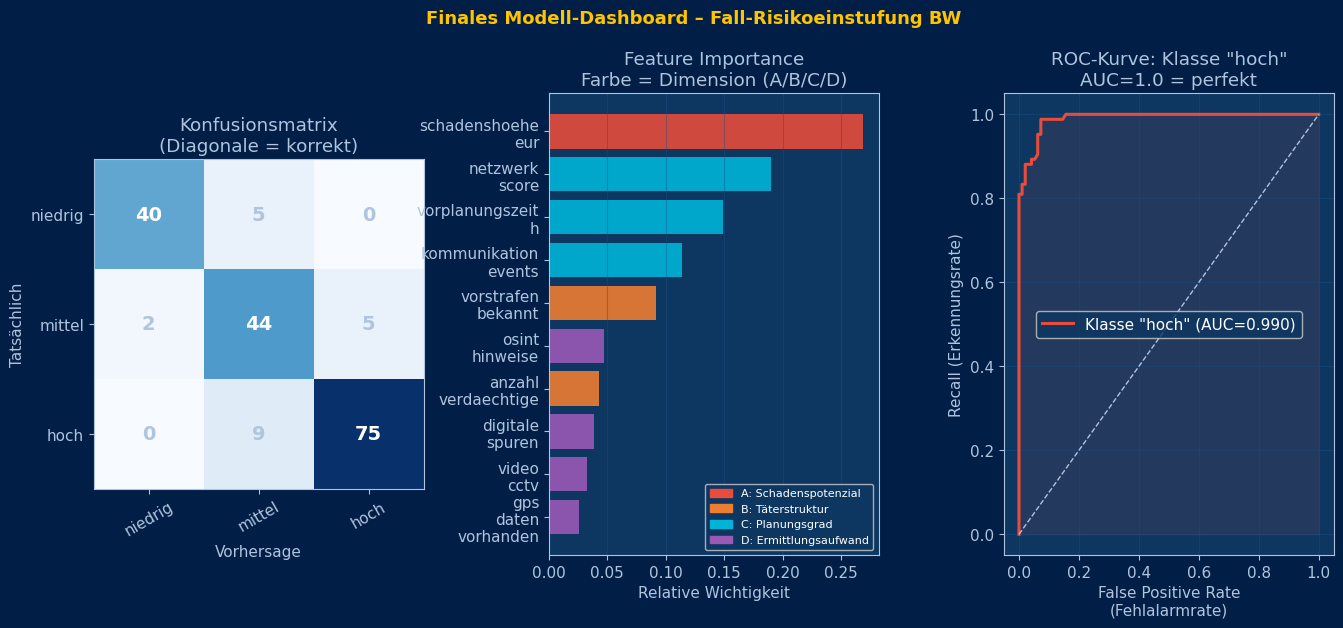


📋 ML-ZYKLUS ABGESCHLOSSEN:
   ✅ Zielvariable transparent aus 4 Dimensionen definiert
   ✅ Feature-Auswahl begründet (10 von 21 Spalten)
   ✅ Baseline F1=0.872  →  Finales Modell F1=0.885  AUC=0.983

Feature Importance – Top 3:
  1. [A] schadenshoehe_eur: 0.269
  2. [C] netzwerk_score: 0.190
  3. [C] vorplanungszeit_h: 0.149


In [14]:
# ── Abschluss-Dashboard ──────────────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig = plt.figure(figsize=(16, 6))
fig.suptitle('Finales Modell-Dashboard – Fall-Risikoeinstufung BW',
             fontsize=13, color=C['gold'], fontweight='bold', y=1.02)
gs2 = plt.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── Konfusionsmatrix ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs2[0])
cm = confusion_matrix(y_test, y_pred)
ax1.imshow(cm, cmap='Blues')
ax1.set_xticks(range(3)); ax1.set_xticklabels(klassen_reihenfolge, rotation=30)
ax1.set_yticks(range(3)); ax1.set_yticklabels(klassen_reihenfolge)
ax1.set_xlabel('Vorhersage'); ax1.set_ylabel('Tatsächlich')
ax1.set_title('Konfusionsmatrix\n(Diagonale = korrekt)', color=C['lgray'])
for i in range(3):
    for j in range(3):
        ax1.text(j, i, str(cm[i,j]), ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white' if cm[i,j]>cm.max()*0.5 else C['lgray'])

# ── Feature Importance ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs2[1])
fi  = bestes_modell.feature_importances_
idx = np.argsort(fi)[::-1]

# Farbe nach Dimension
dim_farben = {
    'schadenshoehe_eur': C['red'],
    'vorstrafen_bekannt': C['orange'],   'anzahl_verdaechtige': C['orange'],
    'netzwerk_score': C['teal'],         'vorplanungszeit_h': C['teal'],
    'kommunikation_events': C['teal'],
    'digitale_spuren': C['purple'],      'osint_hinweise': C['purple'],
    'gps_daten_vorhanden': C['purple'],  'video_cctv': C['purple'],
}
farben_sorted = [dim_farben.get(FEATS_VERWENDET[i], C['lgray']) for i in idx]

namen = [f.replace('_', '\n') for f in [FEATS_VERWENDET[i] for i in idx]]
ax2.barh(namen[::-1], fi[idx][::-1], color=farben_sorted[::-1], alpha=0.9)
ax2.set_title('Feature Importance\nFarbe = Dimension (A/B/C/D)',
              color=C['lgray'])
ax2.set_xlabel('Relative Wichtigkeit'); ax2.grid(True, axis='x')

# Legende für Dimensionen
from matplotlib.patches import Patch
legende = [Patch(color=C['red'],   label='A: Schadenspotenzial'),
           Patch(color=C['orange'],label='B: Täterstruktur'),
           Patch(color=C['teal'],  label='C: Planungsgrad'),
           Patch(color=C['purple'],label='D: Ermittlungsaufwand')]
ax2.legend(handles=legende, fontsize=8, loc='lower right')

# ── ROC-Kurve: Klasse "hoch" ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs2[2])
hoch_idx = klassen_reihenfolge.index('hoch')
y_bin    = (y_test == hoch_idx).astype(int)
fpr, tpr, _ = roc_curve(y_bin, y_prob[:, hoch_idx])
auc_h = roc_auc_score(y_bin, y_prob[:, hoch_idx])

ax3.plot(fpr, tpr, color=C['red'],  lw=2.2,
         label=f'Klasse "hoch" (AUC={auc_h:.3f})')
ax3.plot([0,1],[0,1], color=C['lgray'], ls='--', lw=1)
ax3.fill_between(fpr, tpr, alpha=0.1, color=C['red'])
ax3.set_xlabel('False Positive Rate\n(Fehlalarmrate)'); ax3.set_ylabel('Recall (Erkennungsrate)')
ax3.set_title('ROC-Kurve: Klasse "hoch"\nAUC=1.0 = perfekt', color=C['lgray'])
ax3.legend(); ax3.grid(True)

plt.tight_layout(); plt.show()

print('\n📋 ML-ZYKLUS ABGESCHLOSSEN:')
print('   ✅ Zielvariable transparent aus 4 Dimensionen definiert')
print('   ✅ Feature-Auswahl begründet (10 von 21 Spalten)')
print(f'   ✅ Baseline F1={f1_lr:.3f}  →  Finales Modell F1={f1_f:.3f}  AUC={auc_f:.3f}')
print()
print('Feature Importance – Top 3:')
for rang, i in enumerate(np.argsort(fi)[::-1][:3], 1):
    dim = {'schadenshoehe_eur':'A','vorstrafen_bekannt':'B',
           'anzahl_verdaechtige':'B','netzwerk_score':'C',
           'vorplanungszeit_h':'C','kommunikation_events':'C',
           'digitale_spuren':'D','osint_hinweise':'D',
           'gps_daten_vorhanden':'D','video_cctv':'D'}.get(FEATS_VERWENDET[i],'?')
    print(f'  {rang}. [{dim}] {FEATS_VERWENDET[i]}: {fi[i]:.3f}')


---

## Zusammenfassung

| Schritt | Was wir getan haben | Warum |
|---|---|---|
| **Zielvariable definieren** | Transparentes Bewertungsschema aus 4 Dimensionen | Labels müssen nachvollziehbar sein |
| **Feature-Auswahl** | 10 von 21 Features – mit Begründung für Ausschlüsse | Modelle sollen keine bias-behafteten Merkmale nutzen |
| **Preprocessing** | Kodierung + Skalierung + Split | Modelle brauchen Zahlen, vergleichbare Skalen, getrennte Daten |
| **Baseline** | Logistische Regression | Referenzpunkt – ohne ihn kein Vergleich |
| **Overfitting** | Provoziert & diagnostiziert | Häufigstes Praxisproblem |
| **Regularisierung** | L2 + Early Stopping | Gegenmittel |
| **Grid Search** | 120 Trainingsläufe, kreuzvalidiert | Robuster, fairer Parametervergleich |
| **Test-Evaluation** | Einmalig, ungesehen | Ehrlicher Score |

---

### Die drei wichtigsten Prinzipien

> **1. Labels zuerst.** Schlechte Definitionen produzieren schlechte Modelle –  
> egal wie gut die Technik ist.

> **2. Feature-Auswahl begründen.** Nur weil ein Merkmal korreliert,  
> darf es noch lange nicht verwendet werden (Bias, Diskriminierung).

> **3. Test-Set = heilig.** Einmal öffnen, ganz am Ende.

---

### Praxishinweis für den Polizeieinsatz

Die Fall-Risikoeinstufung ist ein **Unterstützungswerkzeug**, kein Entscheidungsautomat.  
Das Modell liefert eine Wahrscheinlichkeit – die Entscheidung trifft immer der Mensch.  
Für den operativen Einsatz wären zudem notwendig: Validierung auf echten Daten,  
rechtliche Prüfung (DSGVO, AI Act), Dokumentation, Auditierbarkeit.

---

**Nächstes Notebook:** NB-05 (S 2.2) – Generative KI & LLMs: Tokenisierung, Attention, Embeddings

---
**KI Advanced · IA1017000 · HfPolBW · Marc Brandt**
